In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('D:/projects/ab-testing-analysis/data/raw/marketing_AB.csv')

df = df.drop(columns=['Unnamed: 0'])

print('\nRows and Columns in dataset:')
print('-' * 50)
print(df.shape)

print('\n Summary:')
print('-' * 50)
df.info()

print('\n Value Counts in test group column:')
print('-' * 50)
print(df['test group'].value_counts())

print('\n Value Counts in converted column:')
print('-' * 50)
print(df['converted'].value_counts())

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate user IDs: {df['user id'].duplicated().sum()}")

print()
print(df.isnull().sum())
print()
print((df == '').sum())

print(f"\nmost ads day: {df['most ads day'].unique()}")
print(f"\ntest group: {df['test group'].unique()}")

df.to_csv('../data/processed/cleaned_marketing_data.csv', index=False)



Rows and Columns in dataset:
--------------------------------------------------
(588101, 6)

 Summary:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB

 Value Counts in test group column:
--------------------------------------------------
test group
ad     564577
psa     23524
Name: count, dtype: int64

 Value Counts in converted column:
--------------------------------------------------
converted
False    573258
True      14843
Name: count, dtype: int64

Duplicate rows: 0
Duplicate user IDs:

In [4]:
psa_group = df[df['test group'] == 'psa']

psa_conversion_rate = psa_group['converted'].mean()

print(f"PSA (control) conversion rate: {psa_conversion_rate:.4f}")
print(f"PSA (control) conversion rate: {psa_conversion_rate * 100:.2f}%")

PSA (control) conversion rate: 0.0179
PSA (control) conversion rate: 1.79%


In [14]:
ad_group = df[df['test group'] == 'ad']

ad_conversion_rate = ad_group['converted'].mean()

print(f"Ad (test) conversion rate: {ad_conversion_rate:.4f}")
print(f"Ad (test) conversion rate: {ad_conversion_rate * 100:.2f}%")

raw_difference = ad_conversion_rate - psa_conversion_rate

print(f"\nRaw difference: {raw_difference:.4f}")
print(f"Raw difference: {raw_difference * 100:.2f} percentage points")

Ad (test) conversion rate: 0.0255
Ad (test) conversion rate: 2.55%

Raw difference: 0.0077
Raw difference: 0.77 percentage points


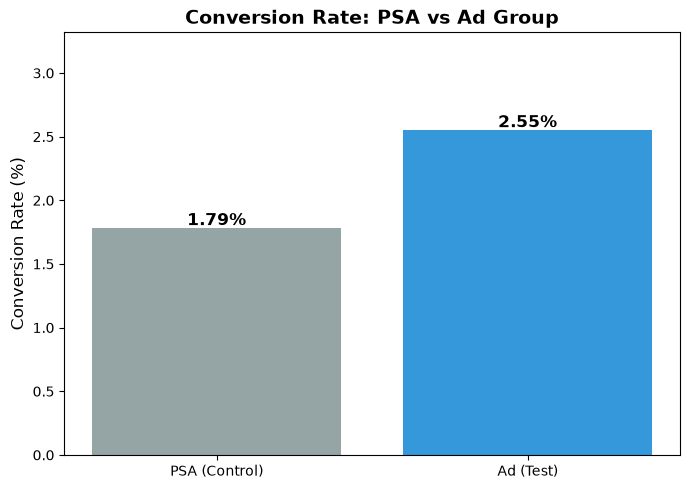

In [28]:
groups = ['PSA (Control)', 'Ad (Test)']
rates = [psa_conversion_rate * 100, ad_conversion_rate * 100]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(groups, rates, color=['#95a5a6', '#3498db'])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02,
             f'{height:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate: PSA vs Ad Group', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3)

plt.tight_layout()
plt.savefig('../outputs/charts/conversion_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()